# Multi-Objective HPO and Cross-Asset Transfer

**Docker image**: `ml4t`

**Chapter 12, Section 12.4**: Advanced Hyperparameter Tuning with Optuna

## Purpose
This notebook demonstrates two advanced HPO concepts:

1. **Multi-objective optimization** with NSGA-II - finding the Pareto frontier
   of IC vs turnover, where no single "best" solution exists
2. **Cross-asset hyperparameter transfer** - testing whether ETF-tuned
   parameters generalize to crypto and futures

## Key Insight
In practice, we care about more than IC. High turnover means high transaction
costs. Multi-objective optimization reveals the trade-off frontier, letting
practitioners choose solutions that balance signal quality against
implementation costs.

## Cross-References
- **Section 12.4**: Multi-objective optimization, IC vs turnover
- **Related**: `04_optuna_tuning` (single-objective), `07_hpo_comparison` (grid vs Optuna)

## References
- Deb et al. (2002). "A Fast and Elitist Multi-Objective GA: NSGA-II"
- Akiba et al. (2019). "Optuna: A Next-generation HPO Framework"

## 1. Setup

In [1]:
"""Multi-Objective HPO and Cross-Asset Transfer - demonstrate NSGA-II multi-objective tuning and hyperparameter transfer."""

import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

# LightGBM records synthetic feature names when fitted on an array with an eval_set,
# and sklearn then warns at every predict on an array that has none to compare. One
# message, not the category: the fit and the predictions are unaffected.
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names",
    category=UserWarning,
    module="sklearn.utils.validation",
)

import optuna
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from optuna.samplers import NSGAIISampler, TPESampler

from utils.modeling import load_modeling_dataset
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_with_alt


def cross_sectional_ic_mean(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dates: np.ndarray,
    symbols: np.ndarray,
) -> float:
    """Mean cross-sectional Spearman IC across dates in a fold."""
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
        min_obs=3,
    )
    ic_clean = ic_per_date.drop_nulls("ic")
    return float(ic_clean["ic"].mean()) if ic_clean.height else float("nan")


optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
N_TRIALS = 50
SEED = 42

In [3]:
set_global_seeds(SEED)

In [4]:
ASSET_CONFIGS = [
    ("etfs", "fwd_ret_21d"),
    ("crypto_perps_funding", "fwd_ret_8h"),
    ("cme_futures", "fwd_ret_5d"),
]

## 2. Load Features

In [5]:
datasets = {}

for cs_id, label in ASSET_CONFIGS:
    try:
        mds = load_modeling_dataset(cs_id, label)
        datasets[cs_id] = {"mds": mds, "feature_cols": mds.feature_names}
        print(f"{cs_id:30s}  {len(mds.dataset):>9,} rows  {len(mds.feature_names):>3} features")
    except Exception as e:
        print(f"{cs_id:30s}  SKIPPED: {e}")

etfs                              402,526 rows   71 features
crypto_perps_funding               99,851 rows   44 features


cme_futures                       112,681 rows   69 features


## 3. Evaluation Metrics

Two objectives:
1. **IC (Information Coefficient)**: Spearman correlation of predictions with returns
2. **Turnover**: Mean absolute change in predictions (proxy for trading costs)

In [6]:
def compute_turnover(predictions: np.ndarray) -> float:
    """Average absolute change in predictions (proxy for trading costs)."""
    if len(predictions) < 2:
        return 0.0
    pred_min, pred_max = predictions.min(), predictions.max()
    if pred_max - pred_min < 1e-8:
        return 0.0
    pred_norm = (predictions - pred_min) / (pred_max - pred_min)
    return float(np.mean(np.abs(np.diff(pred_norm))))

## 4. Prepare Primary Dataset

ETF is the primary optimization target. Other datasets are used
for cross-asset transfer analysis.

In [7]:
ASSET_CLASSES = list(datasets.keys())
primary_asset = ASSET_CLASSES[0]
primary_data = datasets[primary_asset]
mds = primary_data["mds"]
feature_cols = primary_data["feature_cols"]

df = mds.dataset.to_pandas()
date_col = mds.date_col
split = mds.splits[0]

train_mask = (df[date_col] >= split["train_start"]) & (df[date_col] <= split["train_end"])
val_mask = (df[date_col] >= split["val_start"]) & (df[date_col] <= split["val_end"])

primary_entity_col = mds.entity_cols[0]

X_train = df.loc[train_mask, feature_cols].values
y_train = df.loc[train_mask, mds.label_col].values
X_val = df.loc[val_mask, feature_cols].values
y_val = df.loc[val_mask, mds.label_col].values
dates_val = df.loc[val_mask, date_col].values
symbols_val = df.loc[val_mask, primary_entity_col].values

# Drop NaN labels
valid = np.isfinite(y_train)
X_train, y_train = X_train[valid], y_train[valid]
valid = np.isfinite(y_val)
X_val, y_val = X_val[valid], y_val[valid]
dates_val, symbols_val = dates_val[valid], symbols_val[valid]

print(f"Primary asset: {primary_asset}")
print(f"Train: {len(X_train):,}, Val: {len(X_val):,}, Features: {len(feature_cols)}")

Primary asset: etfs
Train: 165,185, Val: 22,184, Features: 71


## 5. Single-Objective Optimization (Baseline)

Standard IC-only optimization provides a reference point for the
multi-objective analysis.

In [8]:
def single_objective(trial: optuna.Trial) -> float:
    """Optimize for IC only."""
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 32),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        "random_state": SEED,
        "verbose": -1,
        "n_jobs": -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    return cross_sectional_ic_mean(y_val, model.predict(X_val), dates_val, symbols_val)


single_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
single_study.optimize(single_objective, n_trials=N_TRIALS, show_progress_bar=True)

# Compute turnover for best single-objective solution
best_single_params = {**single_study.best_params, "random_state": SEED, "verbose": -1}
best_single_model = lgb.LGBMRegressor(**best_single_params)
best_single_model.fit(X_train, y_train)
best_single_pred = best_single_model.predict(X_val)
best_single_turnover = compute_turnover(best_single_pred)

print(f"Best IC: {single_study.best_value:.4f}, Turnover at best IC: {best_single_turnover:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Best IC: 0.1375, Turnover at best IC: 0.0485


## 6. Multi-Objective Optimization with NSGA-II

NSGA-II finds the Pareto frontier - the set of non-dominated solutions where
improving one objective necessarily harms the other.

In [9]:
def multi_objective(trial: optuna.Trial) -> tuple[float, float]:
    """Optimize for IC (maximize) and Turnover (minimize)."""
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 32),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        "random_state": SEED,
        "verbose": -1,
        "n_jobs": -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return cross_sectional_ic_mean(y_val, y_pred, dates_val, symbols_val), compute_turnover(y_pred)


multi_study = optuna.create_study(
    directions=["maximize", "minimize"],
    sampler=NSGAIISampler(seed=SEED),
)
multi_study.optimize(multi_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"Found {len(multi_study.best_trials)} Pareto-optimal solutions")

  0%|          | 0/50 [00:00<?, ?it/s]

Found 5 Pareto-optimal solutions


## 7. Pareto Frontier Visualization

Points on the frontier are non-dominated: no other solution is better
on both objectives simultaneously.

In [10]:
trials_df = multi_study.trials_dataframe()
trials_df["ic"] = trials_df["values_0"]
trials_df["turnover"] = trials_df["values_1"]

pareto_trials = [t.number for t in multi_study.best_trials]
trials_df["pareto"] = trials_df["number"].isin(pareto_trials)

non_pareto = trials_df[~trials_df["pareto"]]
pareto_df = trials_df[trials_df["pareto"]].sort_values("turnover")

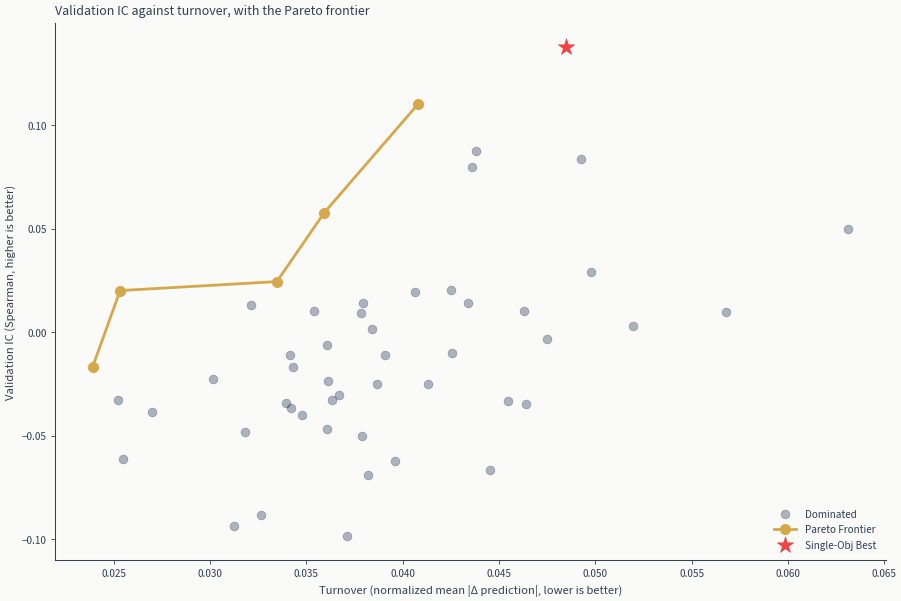

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))

# Dominated solutions
ax.scatter(
    non_pareto["turnover"],
    non_pareto["ic"],
    s=40,
    alpha=0.35,
    color=COLORS["slate"],
    label="Dominated",
    zorder=2,
)

# Pareto frontier
ax.plot(
    pareto_df["turnover"],
    pareto_df["ic"],
    "o-",
    color=COLORS["amber"],
    markersize=8,
    linewidth=2,
    label="Pareto Frontier",
    zorder=3,
)

# Single-objective best
ax.scatter(
    [best_single_turnover],
    [single_study.best_value],
    s=150,
    marker="*",
    color=COLORS["negative"],
    label="Single-Obj Best",
    zorder=4,
)

ax.set_xlabel("Turnover (normalized mean |Δ prediction|, lower is better)")
ax.set_ylabel("Validation IC (Spearman, higher is better)")
ax.set_title("Validation IC against turnover, with the Pareto frontier")
ax.legend(loc="lower right")
show_with_alt(
    fig,
    "Scatter of validation IC against turnover, one point per trial, with the "
    "non-dominated points joined into a frontier and the single-objective best marked "
    "by a star.",
)

**Interpretation**: The Pareto frontier quantifies the IC–turnover trade-off.
Configurations below and to the right are dominated. The frontier's curvature
shows where marginal IC gains come at rapidly increasing turnover cost.
The single-objective best (star) may not lie on the frontier if it trades
off too much turnover for its IC level.

## 8. Pareto Frontier Analysis

In [12]:
min_turnover_trial = pareto_df.loc[pareto_df["turnover"].idxmin()]
max_ic_trial = pareto_df.loc[pareto_df["ic"].idxmax()]

extremes_df = pl.DataFrame(
    {
        "solution": ["Lowest Turnover", "Highest IC", "Single-Obj (IC-only)"],
        "ic": [
            round(min_turnover_trial["ic"], 4),
            round(max_ic_trial["ic"], 4),
            round(single_study.best_value, 4),
        ],
        "turnover": [
            round(min_turnover_trial["turnover"], 4),
            round(max_ic_trial["turnover"], 4),
            round(best_single_turnover, 4),
        ],
    }
)
extremes_df

solution,ic,turnover
str,f64,f64
"""Lowest Turnover""",-0.0168,0.0239
"""Highest IC""",0.1101,0.0408
"""Single-Obj (IC-only)""",0.1375,0.0485


## 9. Cross-Asset Hyperparameter Transfer

Do ETF-tuned hyperparameters generalize to other asset classes? We take the
highest-scoring ETF configuration and score it on crypto and futures data, using the
features the three share.

In [13]:
best_params = {**single_study.best_params, "random_state": SEED, "verbose": -1}
transfer_results = {}

for asset_class, data in datasets.items():
    asset_mds = data["mds"]
    feature_cols_asset = data["feature_cols"]

    common_features = [f for f in feature_cols_asset if f in feature_cols]
    if len(common_features) < 5:
        print(f"{asset_class}: Skipping (only {len(common_features)} common features)")
        continue

    df_asset = asset_mds.dataset.to_pandas()
    date_col_asset = asset_mds.date_col
    split_asset = asset_mds.splits[0]

    train_m = (df_asset[date_col_asset] >= split_asset["train_start"]) & (
        df_asset[date_col_asset] <= split_asset["train_end"]
    )
    val_m = (df_asset[date_col_asset] >= split_asset["val_start"]) & (
        df_asset[date_col_asset] <= split_asset["val_end"]
    )

    asset_entity_col = asset_mds.entity_cols[0]

    X_train_asset = df_asset.loc[train_m, common_features].values
    y_train_asset = df_asset.loc[train_m, asset_mds.label_col].values
    X_val_asset = df_asset.loc[val_m, common_features].values
    y_val_asset = df_asset.loc[val_m, asset_mds.label_col].values
    dates_val_asset = df_asset.loc[val_m, date_col_asset].values
    symbols_val_asset = df_asset.loc[val_m, asset_entity_col].values

    v = np.isfinite(y_train_asset)
    X_train_asset, y_train_asset = X_train_asset[v], y_train_asset[v]
    v = np.isfinite(y_val_asset)
    X_val_asset, y_val_asset = X_val_asset[v], y_val_asset[v]
    dates_val_asset, symbols_val_asset = dates_val_asset[v], symbols_val_asset[v]

    if len(X_train_asset) < 100:
        print(f"{asset_class}: Skipping (only {len(X_train_asset)} train rows)")
        continue

    model = lgb.LGBMRegressor(**best_params)
    model.fit(X_train_asset, y_train_asset)
    y_pred = model.predict(X_val_asset)

    transfer_results[asset_class] = {
        "ic": cross_sectional_ic_mean(y_val_asset, y_pred, dates_val_asset, symbols_val_asset),
        "turnover": compute_turnover(y_pred),
        "n_features": len(common_features),
    }

crypto_perps_funding: Skipping (only 3 common features)


In [14]:
for asset_class in transfer_results:
    r = transfer_results[asset_class]
    print(f"{asset_class}: IC={r['ic']:.4f} ({r['n_features']} common features)")

etfs: IC=0.1375 (71 common features)
cme_futures: IC=0.0210 (18 common features)


## 10. Asset-Specific Tuning Comparison

Tune specifically for each non-primary asset and compare against
transferred ETF parameters.

In [15]:
# Factory to avoid closure-over-loop-variable issue
def make_asset_objective(X_tr_, y_tr_, X_va_, y_va_, dates_va_, symbols_va_):
    """Create an Optuna objective function for asset-specific LightGBM tuning."""

    def _objective(trial: optuna.Trial) -> float:
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 200),
            "max_depth": trial.suggest_int("max_depth", 2, 6),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 8, 32),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
            "random_state": SEED,
            "verbose": -1,
        }
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr_, y_tr_)
        return cross_sectional_ic_mean(y_va_, model.predict(X_va_), dates_va_, symbols_va_)

    return _objective

In [16]:
# Tune each non-primary asset and compare against transferred parameters
asset_specific_results = {
    primary_asset: {"ic": single_study.best_value, "turnover": best_single_turnover}
}

for asset_class, data in datasets.items():
    if asset_class == primary_asset or asset_class not in transfer_results:
        continue

    asset_mds = data["mds"]
    common_features = [f for f in data["feature_cols"] if f in feature_cols]
    df_asset = asset_mds.dataset.to_pandas()
    date_col_asset = asset_mds.date_col
    split_asset = asset_mds.splits[0]

    train_m = (df_asset[date_col_asset] >= split_asset["train_start"]) & (
        df_asset[date_col_asset] <= split_asset["train_end"]
    )
    val_m = (df_asset[date_col_asset] >= split_asset["val_start"]) & (
        df_asset[date_col_asset] <= split_asset["val_end"]
    )
    asset_entity_col = asset_mds.entity_cols[0]

    X_tr = df_asset.loc[train_m, common_features].values
    y_tr = df_asset.loc[train_m, asset_mds.label_col].values
    X_va = df_asset.loc[val_m, common_features].values
    y_va = df_asset.loc[val_m, asset_mds.label_col].values
    dates_va = df_asset.loc[val_m, date_col_asset].values
    symbols_va = df_asset.loc[val_m, asset_entity_col].values
    v = np.isfinite(y_tr)
    X_tr, y_tr = X_tr[v], y_tr[v]
    v = np.isfinite(y_va)
    X_va, y_va = X_va[v], y_va[v]
    dates_va, symbols_va = dates_va[v], symbols_va[v]

    print(f"Tuning for {asset_class}...")
    asset_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
    asset_study.optimize(
        make_asset_objective(X_tr, y_tr, X_va, y_va, dates_va, symbols_va),
        n_trials=N_TRIALS // 2,
        show_progress_bar=True,
    )
    best_asset_params = {**asset_study.best_params, "random_state": SEED, "verbose": -1}
    best_model = lgb.LGBMRegressor(**best_asset_params)
    best_model.fit(X_tr, y_tr)
    asset_specific_results[asset_class] = {
        "ic": asset_study.best_value,
        "turnover": compute_turnover(best_model.predict(X_va)),
    }
    print(f"  Asset-specific IC: {asset_study.best_value:.4f}")

Tuning for cme_futures...


  0%|          | 0/25 [00:00<?, ?it/s]

  Asset-specific IC: 0.0642


## 11. Transfer Analysis Summary

In [17]:
transfer_rows = []
for asset_class in ASSET_CLASSES:
    if asset_class not in transfer_results or asset_class not in asset_specific_results:
        continue
    t_ic = transfer_results[asset_class]["ic"]
    s_ic = asset_specific_results[asset_class]["ic"]
    eff = t_ic / s_ic * 100 if s_ic != 0 else 0.0
    transfer_rows.append(
        {
            "symbol": asset_class,
            "transfer_ic": round(t_ic, 4),
            "specific_ic": round(s_ic, 4),
            "difference": round(s_ic - t_ic, 4),
            "transfer_efficiency_pct": round(eff, 1),
        }
    )

transfer_summary = pl.DataFrame(transfer_rows)
transfer_summary

symbol,transfer_ic,specific_ic,difference,transfer_efficiency_pct
str,f64,f64,f64,f64
"""etfs""",0.1375,0.1375,0.0,100.0
"""cme_futures""",0.021,0.0642,0.0432,32.7


**Interpretation**: the table above is the transfer gap. Two things about how to
read it. The ETF row is a tautology: applying the ETF-tuned configuration to ETFs is
the asset-specific case, so its efficiency is one hundred percent by construction and
carries no information. And efficiency is a ratio of two small numbers, so it
magnifies whatever the denominator does; where the transferred IC crosses zero the
ratio changes sign, which is a fact about the ratio rather than about the
configuration.

What the row that is not a tautology says is that a configuration tuned on one asset
class does not carry its validation IC to another. Feature distributions and
signal-to-noise differ across classes, and the hyperparameters that suit one are
fitted to that. Where the transfer costs more than it saves is a compute question
with a different answer per desk, and this table is not the place it gets settled.

## 12. Transfer Visualization

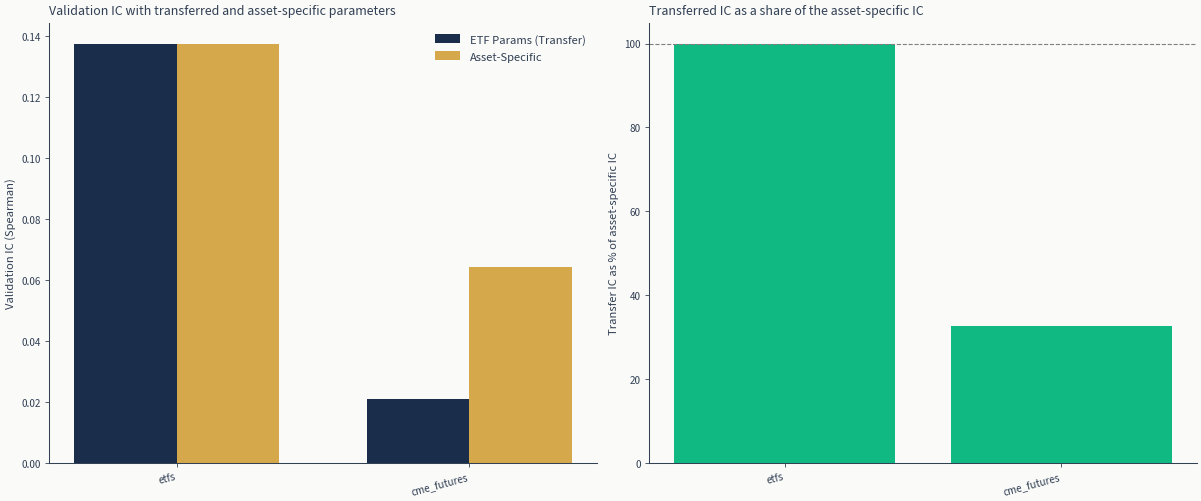

In [18]:
if len(transfer_rows) < 2:
    display(
        Markdown(
            "**No transfer chart**: it needs at least two asset classes that finished "
            "both the transfer evaluation and their own search, and this run produced "
            "fewer than two. The load table says which case studies were available, and "
            "the skip lines in the two sections above say which of those were dropped "
            "for too few shared features or too few training rows."
        )
    )
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    asset_names = [r["symbol"] for r in transfer_rows]
    transfer_ics = [r["transfer_ic"] for r in transfer_rows]
    specific_ics = [r["specific_ic"] for r in transfer_rows]
    efficiencies = [r["transfer_efficiency_pct"] for r in transfer_rows]

    x = np.arange(len(asset_names))
    width = 0.35

    # Left: IC comparison
    ax1 = axes[0]
    ax1.bar(
        x - width / 2, transfer_ics, width, label="ETF Params (Transfer)", color=COLORS["slate"]
    )
    ax1.bar(x + width / 2, specific_ics, width, label="Asset-Specific", color=COLORS["amber"])
    ax1.set_xticks(x)
    ax1.set_xticklabels(asset_names, rotation=15, ha="right")
    ax1.set_ylabel("Validation IC (Spearman)")
    ax1.set_title("Validation IC with transferred and asset-specific parameters")
    ax1.legend(fontsize=9)

    # Right: transfer efficiency
    ax2 = axes[1]
    ax2.bar(x, efficiencies, color=COLORS["positive"])
    ax2.axhline(100, linestyle="--", color="gray", linewidth=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(asset_names, rotation=15, ha="right")
    ax2.set_ylabel("Transfer IC as % of asset-specific IC")
    ax2.set_title("Transferred IC as a share of the asset-specific IC")

    show_with_alt(
        fig,
        "Two panels sharing an asset-class axis. Left: paired bars of validation IC, one "
        "for the ETF-tuned parameters and one for parameters tuned on that asset class. "
        "Right: the first as a percentage of the second, against a dashed line at one "
        "hundred percent, where the ETF bar sits by construction.",
    )

## Key Takeaways

1. **Multi-objective HPO reveals hidden trade-offs**: Single-objective
   optimization produces one "best" solution that hides the IC–turnover
   trade-off. NSGA-II exposes the Pareto frontier, letting practitioners
   choose solutions matched to their transaction cost tolerance.

2. **Cross-asset transfer is fragile here**: ETF-tuned hyperparameters
   collapse to a near-zero (slightly negative) validation IC on CME
   futures, versus a clearly positive asset-specific IC (see the transfer
   table). Crypto is excluded outright: only 3 features overlap because the
   ETF and crypto pipelines run different feature engineering. The lesson is
   the converse of "tune once, deploy everywhere": when feature
   distributions differ across asset classes, asset-specific tuning is
   mandatory, not optional.

3. **Marginal IC has increasing turnover cost**: The Pareto frontier's
   curvature shows that the last few basis points of IC improvement
   require disproportionate increases in turnover, making them
   unprofitable after transaction costs.

4. **Overfitting risk grows with tuning intensity**: More trials and
   objectives increase the risk of validation overfitting. Walk-forward
   HPO (see `04_optuna_tuning`) mitigates this by evaluating on temporal
   out-of-sample folds.

**Next**: See `04_optuna_tuning` for the full single-objective workflow with
walk-forward HPO, or `07_hpo_comparison` for grid vs Optuna efficiency.